# Q-factorisation on Gridworld Maze

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot, get_free_cells, sample_goals)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_html, plot_min_steps_and_min_time
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss, contrastive_loss
from networks import snapshot_named_parameters


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
class FactorisedDQN_QNetwork(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        num_actions: int,
        goal_dim: int = 2,
        hidden_dim: int = 128,
        rep_dim: int = 64,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.num_actions = num_actions
        self.action_dim = num_actions
        self.goal_dim = goal_dim
        self.rep_dim = rep_dim

        self.sa_encoder = nn.Sequential(
            nn.Linear(obs_dim + self.action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

        self.goal_encoder = nn.Sequential(
            nn.Linear(goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def encode_goal(self, goal: torch.Tensor) -> torch.Tensor:
        psi = self.goal_encoder(goal)
        psi = F.normalize(psi, p=2, dim=-1, eps=1e-8)
        return psi

    def encode_state_action(self, obs: torch.Tensor, act: torch.Tensor) -> torch.Tensor:
        sa = torch.cat([obs, act], dim=-1)
        phi = self.sa_encoder(sa)
        phi = F.normalize(phi, p=2, dim=-1, eps=1e-8)
        return phi

    def forward(
        self,
        obs: torch.Tensor,
        act: torch.Tensor,
        goal: torch.Tensor,
    ) -> torch.Tensor:
        phi_sa = self.encode_state_action(obs, act)      # [B, D]
        psi_z = self.encode_goal(goal)                   # [B, D]
        q_vals = (phi_sa * psi_z).sum(dim=-1, keepdim=True)  # [B, 1]
        return q_vals

    def q_val_for_argmax_action(self, obs: torch.Tensor, goal: torch.Tensor) -> torch.Tensor:
        B = obs.shape[0]
        A = self.num_actions

        act_onehot = F.one_hot(
            torch.arange(A, device=obs.device),
            num_classes=self.action_dim
        ).float()                                        # [A, A]
        act_onehot = act_onehot.unsqueeze(0).expand(B, -1, -1)   # [B, A, A]

        obs_rep = obs.unsqueeze(1).expand(-1, A, -1)             # [B, A, obs_dim]
        obs_flat = obs_rep.reshape(B * A, self.obs_dim)          # [B*A, obs_dim]
        act_flat = act_onehot.reshape(B * A, self.action_dim)    # [B*A, A]

        phi_sa = self.encode_state_action(obs_flat, act_flat)    # [B*A, D]
        phi_sa = phi_sa.view(B, A, self.rep_dim)                 # [B, A, D]

        psi_z = self.encode_goal(goal)                           # [B, D]
        psi_rep = psi_z.unsqueeze(1).expand(B, A, -1)           # [B, A, D]

        q_vals = (phi_sa * psi_rep).sum(dim=-1)                 # [B, A]
        return q_vals
    
    def forward_with_task_embedding(
        self,
        obs: torch.Tensor,
        act: torch.Tensor,
        task_embedding: torch.Tensor,
        normalize_embedding: bool = False,
    ) -> torch.Tensor:
        """
        Compute Q(obs, act | psi) directly from a provided task embedding.

        obs: [B, obs_dim]
        act: [B, action_dim]
        task_embedding: [B, rep_dim] or [rep_dim]
        """
        phi_sa = self.encode_state_action(obs, act)  # [B, D]

        if task_embedding.dim() == 1:
            task_embedding = task_embedding.unsqueeze(0).expand(obs.shape[0], -1)

        psi_z = (
            F.normalize(task_embedding, p=2, dim=-1, eps=1e-8)
            if normalize_embedding
            else task_embedding
        )

        q_vals = (phi_sa * psi_z).sum(dim=-1, keepdim=True)   # [B, 1]
        return q_vals
    
    def q_val_for_argmax_action_from_embedding(
        self,
        obs: torch.Tensor,
        task_embedding: torch.Tensor,
        normalize_embedding: bool = False,
    ) -> torch.Tensor:
        """
        Compute Q-values for all actions using a provided task embedding.

        obs: [B, obs_dim]
        task_embedding: [B, rep_dim] or [rep_dim]
        returns: [B, A]
        """
        B = obs.shape[0]
        A = self.num_actions

        act_onehot = F.one_hot(
            torch.arange(A, device=obs.device),
            num_classes=self.action_dim
        ).float()                                             # [A, A]
        act_onehot = act_onehot.unsqueeze(0).expand(B, -1, -1)  # [B, A, A]

        obs_rep = obs.unsqueeze(1).expand(-1, A, -1)          # [B, A, obs_dim]
        obs_flat = obs_rep.reshape(B * A, self.obs_dim)       # [B*A, obs_dim]
        act_flat = act_onehot.reshape(B * A, self.action_dim) # [B*A, A]

        phi_sa = self.encode_state_action(obs_flat, act_flat) # [B*A, D]
        phi_sa = phi_sa.view(B, A, self.rep_dim)              # [B, A, D]

        if task_embedding.dim() == 1:
            task_embedding = task_embedding.unsqueeze(0).expand(B, -1)

        psi_z = (
            F.normalize(task_embedding, p=2, dim=-1, eps=1e-8)
            if normalize_embedding
            else task_embedding
        )

        psi_rep = psi_z.unsqueeze(1).expand(B, A, -1)         # [B, A, D]
        q_vals = (phi_sa * psi_rep).sum(dim=-1)               # [B, A]
        return q_vals

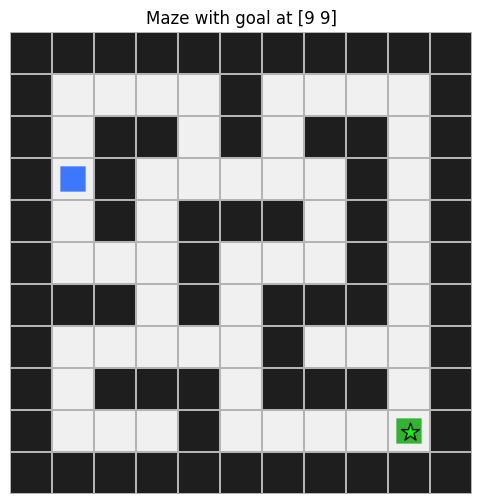

In [3]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

class NextStateEncoder(nn.Module):
    def __init__(self, obs_dim: int, hidden_dim: int = 128, rep_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def forward(self, next_obs: torch.Tensor) -> torch.Tensor:
        z = self.net(next_obs)
        z = F.normalize(z, dim=-1)
        return z

In [ ]:
def dqn_train_dot_head_online(
    seed: int = 42,
    q_network=None,
    q_target_network=None,
    env=None,
    buffer_capacity=None,
    obs_dim=None,
    device=None,
    total_steps=150000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=100000,
    train_freq=4,
    goal=None,
    td_steps=1,
    make_env=None,
    epsilon_reduction=False,
    eps_start_transfer=0.2,
    eps_end_transfer=0.05,
    eps_decay_steps_transfer=20000,
    lr_sa=5e-4,
    lr_ns=1e-3,
    lr_td=1e-3,
    next_state_encoder=None,
    temperature=0.05,
    contrastive_reg_coef=0.0,
    sigreg_coef=0.0,
    dyn_coef=1.0,
    freeze_sa_encoder=False,
    early_stop_reward=0.99,
    early_stop_patience=5,
    enable_early_stop=True,

):
    if q_network is None:
        raise ValueError("q_network must be provided")
    if q_target_network is None:
        raise ValueError("q_target_network must be provided")
    if env is None:
        raise ValueError("env must be provided")
    if buffer_capacity is None:
        raise ValueError("buffer_capacity must be provided")
    if goal is None:
        raise ValueError("goal must be provided")
    if make_env is None:
        raise ValueError("make_env must be provided")

    if device is None:
        device = next(q_network.parameters()).device

    if obs_dim is None:
        obs_dim = int(env.observation_space.shape[0])

    set_seed(seed)

    num_actions = env.action_space.n

    if not freeze_sa_encoder:
        if next_state_encoder is None:
            raise ValueError("next_state_encoder must be provided when freeze_sa_encoder=False")
        for p in q_network.sa_encoder.parameters():
            p.requires_grad_(True)
        for p in q_target_network.sa_encoder.parameters():
            p.requires_grad_(True)

        opt_shared = optim.Adam(
            [
                {"params": q_network.sa_encoder.parameters(), "lr": lr_sa},
                {"params": next_state_encoder.parameters(), "lr": lr_ns},
            ]
        )
    else:
        for p in q_network.sa_encoder.parameters():
            p.requires_grad_(False)
        for p in q_target_network.sa_encoder.parameters():
            p.requires_grad_(False)
        opt_shared = None

    opt_goal = optim.Adam(
        [{"params": q_network.goal_encoder.parameters(), "lr": lr_td}]
    )

    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    obs, _ = env.reset()
    global_step = 0
    eval_returns = []
    eval_returns_time = []
    start_time = time.perf_counter()
    min_steps = None
    min_time = None
    success_streak = 0

    contrastive_loss_val = torch.tensor(0.0, device=device)
    sigreg_loss_val = torch.tensor(0.0, device=device)
    dyn_total_loss = torch.tensor(0.0, device=device)
    td_loss = torch.tensor(0.0, device=device)
    all_logits = None

    q_network.train()
    q_target_network.train()
    if next_state_encoder is not None:
        next_state_encoder.train()

    while global_step < total_steps:
        if epsilon_reduction:
            frac = min(1.0, global_step / eps_decay_steps_transfer)
            eps = eps_start_transfer + frac * (eps_end_transfer - eps_start_transfer)
        else:
            frac = min(1.0, global_step / eps_decay_steps)
            eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t_single = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                q_vals = q_network.q_val_for_argmax_action(obs_t_single, goal_t_single)
                action = int(q_vals.argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        buffer.add_transition(obs, action, rew, next_obs, done)
        obs = next_obs
        global_step += 1

        if done:
            obs, _ = env.reset()

        if len(buffer) >= warmup_steps:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs
            act_t = batch.actions.long()
            rew_t = batch.rewards
            next_obs_t = batch.next_obs
            term_t = batch.terminated.float()
            trunc_t = batch.truncated.float()

            done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)
            if done_t.ndim == 1:
                done_t = done_t.unsqueeze(-1)
            if rew_t.ndim == 1:
                rew_t = rew_t.unsqueeze(-1)

            B = obs_t.shape[0]
            goal_batch = goal_t_single.expand(B, -1)

            act_onehot = F.one_hot(
                act_t.squeeze(-1),
                num_classes=num_actions
            ).float()

            if global_step % train_freq == 0:

                # =================================================
                # 1) TD UPDATE: goal_encoder only
                # =================================================
                phi_td = q_network.encode_state_action(obs_t, act_onehot)
                psi_g = q_network.encode_goal(goal_batch)
                current_q = (phi_td * psi_g).sum(dim=-1)    

                with torch.no_grad():
                    next_q_vals = q_target_network.q_val_for_argmax_action(next_obs_t, goal_batch)
                    next_q = next_q_vals.max(dim=-1, keepdim=True).values
                    gamma_final = gamma ** td_steps
                    target = rew_t + gamma_final * (1.0 - term_t) * next_q

                td_loss = F.mse_loss(current_q, target)

                opt_goal.zero_grad(set_to_none=True)
                td_loss.backward()
                nn.utils.clip_grad_norm_(q_network.goal_encoder.parameters(), 10.0)
                opt_goal.step()

                # =================================================
                # 2) SHARED UPDATE: sa_encoder + next_state_encoder
                #    This is the clean part: fresh forward pass.
                # =================================================
                if not freeze_sa_encoder:
                    # Fresh forward for shared update
                    phi_sa = q_network.encode_state_action(obs_t, act_onehot)
                    psi_g2 = q_network.encode_goal(goal_batch)
                    current_q_shared = (phi_sa * psi_g2.sum(dim=-1)    

                    # Recompute TD loss so sa_encoder can receive TD gradients too
                    with torch.no_grad():
                        next_q_vals2 = q_target_network.q_val_for_argmax_action(next_obs_t, goal_batch)
                        next_q2 = next_q_vals2.max(dim=-1, keepdim=True).values
                        target2 = rew_t + gamma_final * (1.0 - term_t) * next_q2

                    td_loss_shared = F.mse_loss(current_q_shared, target2)

                    # Auxiliary branch
                    z_sa = q_network.encode_state_action(obs_t, act_onehot)
                    z_s_prime = next_state_encoder(next_obs_t)

                    all_logits = z_sa @ z_s_prime.T
                    contrastive_loss_val = contrastive_loss(
                        all_logits,
                        temperature=temperature,
                        reg_coef=contrastive_reg_coef,
                    )

                    if sigreg_coef > 0.0:
                        sigreg_loss_val = sigreg_loss(z_sa)
                    else:
                        sigreg_loss_val = torch.tensor(0.0, device=device)

                    dyn_total_loss = dyn_coef * contrastive_loss_val + sigreg_coef * sigreg_loss_val

                    # if ewc_state is not None:
                    #     if (
                    #         ewc_lambda_sa > 0.0
                    #         and ewc_state.ref_params_sa is not None
                    #         and ewc_state.fisher_sa is not None
                    #     ):
                    #         ewc_sa_loss_val = ewc_regulariser_loss(
                    #             q_network.sa_encoder,
                    #             ewc_state.ref_params_sa,
                    #             ewc_state.fisher_sa,
                    #         )
                    #         dyn_total_loss = dyn_total_loss + ewc_lambda_sa * ewc_sa_loss_val

                    #     if (
                    #         ewc_lambda_ns > 0.0
                    #         and ewc_state.ref_params_ns is not None
                    #         and ewc_state.fisher_ns is not None
                    #     ):
                    #         ewc_ns_loss_val = ewc_regulariser_loss(
                    #             next_state_encoder,
                    #             ewc_state.ref_params_ns,
                    #             ewc_state.fisher_ns,
                    #         )
                    #         dyn_total_loss = dyn_total_loss + ewc_lambda_ns * ewc_ns_loss_val

                    # Combined shared objective
                    shared_loss = td_loss_shared + dyn_total_loss

                    opt_shared.zero_grad(set_to_none=True)
                    shared_loss.backward()

                    nn.utils.clip_grad_norm_(q_network.sa_encoder.parameters(), 10.0)
                    nn.utils.clip_grad_norm_(next_state_encoder.parameters(), 10.0)
                    opt_shared.step()

                else:
                    contrastive_loss_val = torch.tensor(0.0, device=device)
                    sigreg_loss_val = torch.tensor(0.0, device=device)
                    dyn_total_loss = torch.tensor(0.0, device=device)
                    td_loss_shared = torch.tensor(0.0, device=device)
                    ewc_sa_loss_val = torch.tensor(0.0, device=device)
                    ewc_ns_loss_val = torch.tensor(0.0, device=device)

                # =================================================
                # 3) TARGET NETWORK UPDATE
                # =================================================
                with torch.no_grad():
                    for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                        p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % 1000 == 0:
            eval_env = make_env(goal)
            goal_eval_t = torch.tensor(
                np.array(goal, dtype=np.float32),
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            def eval_policy(o):
                o_t = torch.tensor(o, dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    q_vals = q_network.q_val_for_argmax_action(o_t, goal_eval_t)
                    return int(q_vals.argmax(dim=-1).item())

            mean_ret, mean_len = evaluate_policy(eval_env, eval_policy, episodes=8)
            eval_time = time.perf_counter() - start_time
            eval_returns_time.append((eval_time, mean_ret))
            eval_returns.append((global_step, mean_ret))

            if all_logits is not None:
                with torch.no_grad():
                    diag_logits = all_logits.diag().mean().item()
                    offdiag_logits = (
                        (all_logits.sum() - all_logits.diag().sum()) /
                        (all_logits.numel() - all_logits.shape[0])
                    ).item()
            else:
                diag_logits = 0.0
                offdiag_logits = 0.0

            print(
                f"[DQN-dot-head] step={global_step:7d} | eps={eps:.3f} "
                f"| eval_return={mean_ret:.3f} | eval_len={mean_len:.1f} "
                f"| TD={td_loss.item():.4f} "
                f"| Contrastive={contrastive_loss_val.item():.4f} "
                f"| DynTotal={dyn_total_loss.item():.4f} "
                f"| diag={diag_logits:.4f} | offdiag={offdiag_logits:.4f} "
                f"| SigReg={sigreg_loss_val.item():.4f} "
                f"| freeze_sa={freeze_sa_encoder}"
            )

            if mean_ret >= early_stop_reward:
                success_streak += 1
            else:
                success_streak = 0

            if enable_early_stop and success_streak >= early_stop_patience:
                min_steps = global_step
                min_time = eval_time
                print(f"Good policy achieved at step {global_step} with mean return {mean_ret:.3f}")
                print(
                    f"Early stopping triggered at step {global_step} "
                    f"after {success_streak} consecutive evals with "
                    f"mean return >= {early_stop_reward:.2f}"
                )
                eval_env.close()
                break

            eval_env.close()

            eval_env.close()

    goal_tensor = torch.tensor(
        np.array(goal, dtype=np.float32),
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():
        psi_z = q_network.encode_goal(goal_tensor)
        task_embedding = psi_z.squeeze(0).cpu().numpy()

    obs_probe_np = np.array([5.0, 5.0], dtype=np.float32)

    base_env = env.unwrapped if hasattr(env, "unwrapped") else env
    env_action_names = getattr(base_env, "action_names", ["Up", "Down", "Left", "Right"])
    act_probe_idx = env_action_names.index("Up")

    sa_embedding_mean = extract_mean_sa_embedding(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=256,
        device=device,
        as_numpy=True,
    )

    sa_embedding_fixed = extract_fixed_probe_sa_embedding(
        q_network=q_network,
        obs_probe=obs_probe_np,
        act_probe_idx=act_probe_idx,
        num_actions=num_actions,
        device=device,
        as_numpy=True,
    )

    sa_batch_final = extract_sa_batch_for_isotropy(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=1024,
        device=device,
        as_numpy=True,
    )

    env.close()
    return (
        q_network,
        q_target_network,
        next_state_encoder,
        eval_returns,
        eval_returns_time,
        min_steps,
        min_time,
        task_embedding,
        sa_embedding_mean,
        sa_embedding_fixed,
        sa_batch_final,
        buffer,
    )

## Training Loop across goals and seeds

In [5]:
# SEEDS = [42]
# GOALS = [
#     (9, 9), (1, 1), (7, 7), (3, 5), (3, 9), (5, 5),
#     (3, 6), (9, 1), (1, 1), (7, 4), (9, 8), (9, 7)
# ]
SEEDS = [42, 123, 456, 789, 101112]
# GOALS = [(9, 9), (7, 7), (3, 5), (3, 9), (5, 5)]
NUM_GOALS = 8
goal_rng = np.random.default_rng(0)   # same curriculum for all seeds
GOALS = sample_goals(NUM_GOALS, goal_rng, cells=get_free_cells(MAZE_LAYOUT))
print("Sampled GOALS:", GOALS)
BUFFER_CAPACITY = 100000
LR = float(1e-3)

sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["goal_encoder"]  # no q_head in dot-product version

overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)

    # Inspect env to get dimensions
    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    # Base networks: dot-product version
    q_net_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    # Shared next-state encoder across all goals
    next_state_encoder = NextStateEncoder(
        obs_dim=obs_dim,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    seed_task_embedding_memory = []
    seen_goal_labels = []
    weight_history = []
    prev_q_net = None
    prev_q_target = None

    for goal_idx, goal in enumerate(GOALS):
        print(f"\n----- seed={seed}, goal={goal} -----\n")

        if goal_idx == 0:
            # First task: fresh networks
            q_net = deepcopy(q_net_base)
            q_target = deepcopy(q_target_base)
            q_target.load_state_dict(q_net.state_dict())

            for p in q_net.parameters():
                p.requires_grad_(True)

            freeze_sa_encoder = False
            epsilon_reduction = False

        else:
            # Transfer tasks: start from previous trained nets
            if prev_q_net is None or prev_q_target is None:
                raise ValueError("Previous Q-networks are not available for transfer learning.")

            q_net = deepcopy(prev_q_net)
            q_target = deepcopy(prev_q_target)
            q_target.load_state_dict(q_net.state_dict())

            # SA encoder remains trainable in this comparison
            for p in q_net.sa_encoder.parameters():
                p.requires_grad_(True)
            for p in q_target.sa_encoder.parameters():
                p.requires_grad_(True)

            # Goal side remains trainable
            for p in q_net.goal_encoder.parameters():
                p.requires_grad_(True)

            freeze_sa_encoder = False
            epsilon_reduction = False

        # Weight snapshot before training
        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=goal,
                stage_label=f"goal_{goal_idx}_before_train_{goal}",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        # Training call: dot-product trainer
        (
            q_network,
            q_target_network,
            next_state_encoder,
            eval_returns,
            eval_returns_time,
            min_steps,
            min_time,
            task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
        ) = dqn_train_dot_head_online(
            seed=seed,
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=100000,
            warmup_steps=5000,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            eps_start=1.0,
            eps_end=0.05,
            eps_decay_steps=80000,
            train_freq=4,
            goal=goal,
            td_steps=1,
            make_env=make_env,
            epsilon_reduction=epsilon_reduction,
            eps_start_transfer=0.2,
            eps_end_transfer=0.05,
            eps_decay_steps_transfer=20000,
            lr_sa=LR,
            lr_ns=LR,
            lr_td=LR,
            next_state_encoder=next_state_encoder,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            freeze_sa_encoder=freeze_sa_encoder,
        )

        # Weight snapshot after training
        weight_history.append(
            collect_weight_snapshot(
                qnet=q_network,
                goal_label=goal,
                stage_label=f"goal_{goal_idx}_after_train_{goal}",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        # Visualisations
        visualise_q_table(
            goal,
            q_network,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        visualise_embeddings(
            goal=goal,
            q_network=q_network,
            device=DEVICE,
            make_env=make_env,
            action_mode="all_discrete",
        )

        # Task embedding similarity logging
        seed_task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))
        print_goal_embedding_similarity(
            seed_task_embedding_memory,
            goal_labels=seen_goal_labels,
        )

        # Store networks for next transfer step
        prev_q_net = deepcopy(q_network)
        prev_q_target = deepcopy(q_target_network)

        # Store results
        overall_results[goal]["eval_returns"].append(eval_returns)
        overall_results[goal]["eval_returns_time"].append(eval_returns_time)
        overall_results[goal]["min_steps"].append(min_steps)
        overall_results[goal]["min_time"].append(min_time)
        overall_results[goal]["task_embeddings"].append(task_embedding)
        overall_results[goal]["sa_embeddings"].append(sa_embedding_mean)
        overall_results[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
        overall_results[goal]["sa_batches_final"].append(sa_batch_final)

Sampled GOALS: [(7, 7), (4, 1), (1, 1), (2, 5), (5, 3), (1, 3), (3, 1), (9, 5)]

================ SEED 42 ================


----- seed=42, goal=(7, 7) -----

[DQN-dot-head] step=   1000 | eps=0.988 | eval_return=-9.937 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False
[DQN-dot-head] step=   2000 | eps=0.976 | eval_return=-9.850 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False
[DQN-dot-head] step=   3000 | eps=0.964 | eval_return=-9.900 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False
[DQN-dot-head] step=   4000 | eps=0.953 | eval_return=-9.987 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False


/var/folders/2g/2k53tjhj7sz_z3c4ws9dvcsr0000gn/T/ipykernel_59668/159278333.py:177: UserWarning: Using a target size (torch.Size([256, 1])) that is different to the input size (torch.Size([256])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  td_loss = F.mse_loss(current_q, target)


AttributeError: 'FactorisedDQN_QNetwork' object has no attribute 'q_from_embeddings'

In [ ]:
plot_min_steps_and_min_time(overall_results=overall_results, seeds=SEEDS)

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

In [ ]:
GOALS = [(9, 9), (9,8), (9,7)]

drift = compute_embedding_drift(overall_results, q_network, DEVICE)
for goal, cos in drift.items():
    print(goal, "cos(old, final) =", cos)

for goal in GOALS:

    if goal not in overall_results:
        task_embedding = q_network.encode_goal(torch.tensor(goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)).detach().cpu().numpy()
    else:
        task_embedding = overall_results[goal]["task_embeddings"]
    visualise_q_table(goal, q_network, eval_returns=None, task_embedding=task_embedding, device=DEVICE, make_env=make_env)
    visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
    weights_his=weight_history,
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])